In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,KFold,cross_validate,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression,Lasso,Ridge,LinearRegression
from sklearn.ensemble import RandomForestRegressor,HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error,r2_score,root_mean_squared_error

In [3]:
df=pd.read_csv("/content/housing.csv")

In [4]:
df.shape

(20640, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [6]:
target_col=df['median_house_value']

In [7]:
num_cols=df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols=df.select_dtypes(include=['object']).columns.tolist()

In [8]:
print("target_col", target_col)
print('Numerical coloumns',num_cols)
print('Catagorical coloumns',cat_cols)

target_col 0        452600.0
1        358500.0
2        352100.0
3        341300.0
4        342200.0
           ...   
20635     78100.0
20636     77100.0
20637     92300.0
20638     84700.0
20639     89400.0
Name: median_house_value, Length: 20640, dtype: float64
Numerical coloumns ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
Catagorical coloumns ['ocean_proximity']


In [9]:
# Missing value analysis
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [10]:
for each in df.columns:
  print(df[each].value_counts().head(20))

longitude
-118.31    162
-118.30    160
-118.29    148
-118.27    144
-118.32    142
-118.28    141
-118.35    140
-118.36    138
-118.19    135
-118.25    128
-118.37    128
-118.20    126
-118.14    125
-118.26    121
-118.13    121
-118.18    120
-118.34    119
-118.21    118
-118.15    116
-118.12    112
Name: count, dtype: int64
latitude
34.06    244
34.05    236
34.08    234
34.07    231
34.04    221
34.09    212
34.02    208
34.10    203
34.03    193
33.93    181
33.94    175
33.97    172
33.99    168
33.88    164
33.98    162
34.11    162
34.16    159
34.12    158
34.15    157
34.01    156
Name: count, dtype: int64
housing_median_age
52.0    1273
36.0     862
35.0     824
16.0     771
17.0     698
34.0     689
26.0     619
33.0     615
18.0     570
25.0     566
32.0     565
37.0     537
15.0     512
19.0     502
27.0     488
24.0     478
30.0     476
28.0     471
20.0     465
29.0     461
Name: count, dtype: int64
total_rooms
1527.0    18
1613.0    17
1582.0    17
2127.0    16


In [11]:
# Duplicates

df.duplicated().sum()

np.int64(0)

In [12]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


Data Visualization

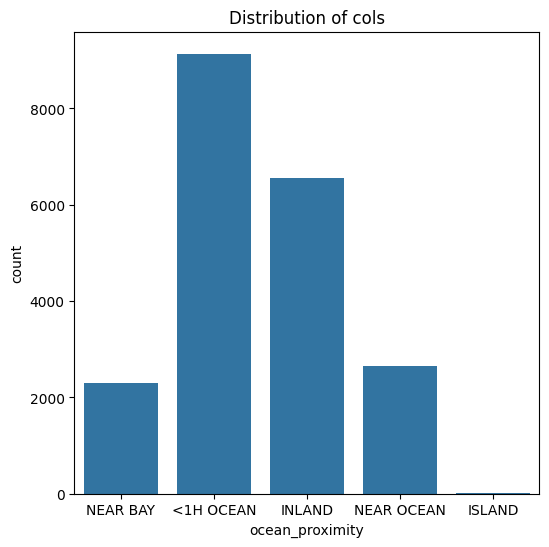

In [13]:
#countplot of catagorical columns
for cols in cat_cols:
  plt.figure(figsize=[6,6])
  sns.countplot(x=cols,data=df)
  plt.title("Distribution of cols")
  plt.show()

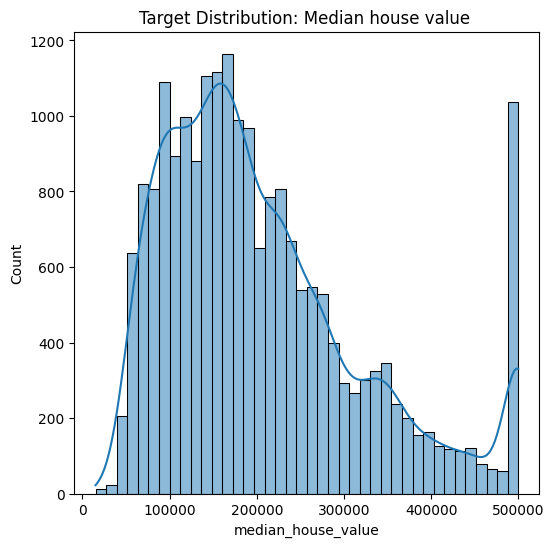

In [14]:
# Target columns distribution
plt.figure(figsize=[6,6])
sns.histplot(target_col,bins=40,kde=True)
plt.title('Target Distribution: Median house value ')
plt.show()

In [15]:
target_col.value_counts()

,count
median_house_value,
500001.0,965
137500.0,122
162500.0,117
112500.0,103
187500.0,93
...,...
34200.0,1
46200.0,1
352000.0,1


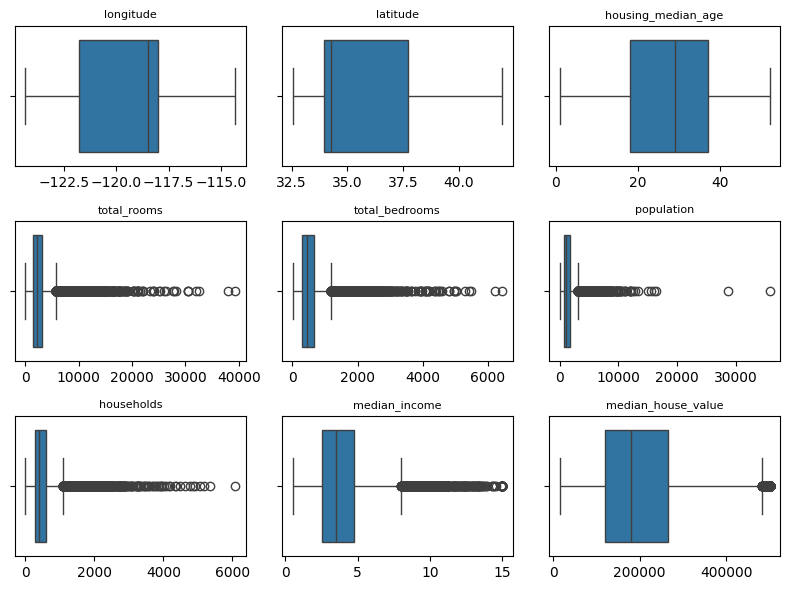

In [16]:
fig,axes=plt.subplots(3,3,figsize=(8,6))
axes=axes.flatten()

for i,col in enumerate(num_cols):
  sns.boxplot(x=df[col],ax=axes[i])
  axes[i].set_title(col,fontsize=8)
  axes[i].set_xlabel('')
plt.tight_layout()
plt.show()


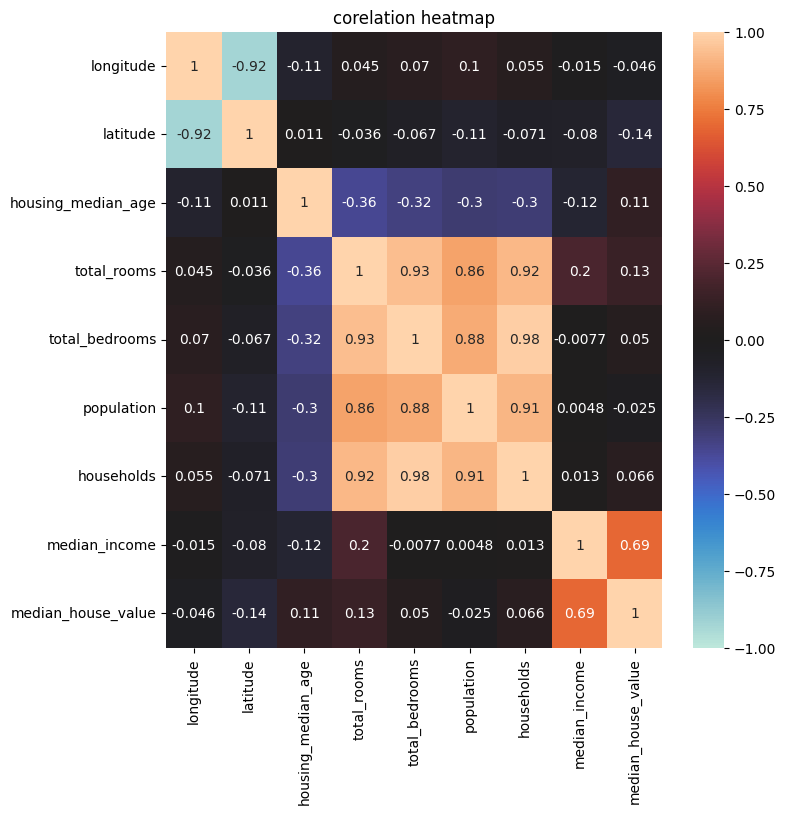

In [17]:
plt.figure(figsize=(8,8))
sns.heatmap(df[num_cols].corr(),annot=True,vmax=1,vmin=-1,center=0)
plt.title("corelation heatmap")
plt.show()

In [18]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

Data Preprocessing


In [19]:
# seperate features and Target

X=df.drop(columns=['median_house_value'],axis=1)
y=df['median_house_value']

In [20]:
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY


In [21]:
y.head()

,median_house_value
0,452600.0
1,358500.0
2,352100.0
3,341300.0
4,342200.0


In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
print(X_train.shape)
print(X_test.shape)

(16512, 9)
(4128, 9)


In [24]:
print(y_train.shape)
print(y_test.shape)

(16512,)
(4128,)


Preprocessing Pipeline

In [25]:
numerical_features=X_train.select_dtypes(include=[np.number]).columns.tolist()
catagorical_features=X_train.select_dtypes(exclude=[np.number]).columns.tolist()


In [26]:
print('Numerical features',numerical_features)
print('catagorical_features',catagorical_features)

Numerical features ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
catagorical_features ['ocean_proximity']


In [27]:
# Numerical features Preprocessing
numeric_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='median')),
        ('sacler',StandardScaler())
    ]
)

# Catagorical features preprocessing
catagorical_transformer=Pipeline(
    steps=[
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('onehot',OneHotEncoder(handle_unknown='ignore'))
    ]
)

# Preprocessing pipeline

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', catagorical_transformer, catagorical_features)
    ]
)

Baseline model(No CV,No Tuning)

In [28]:
baseline_model=Pipeline(
    steps=[
        ('preprocess',preprocess),
        ('model',LinearRegression())

        ]


)

In [29]:
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sacler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

Evaluation of Baseline Model


In [30]:
train_baseline_pred=baseline_model.predict(X_train)
test_baseline_pred=baseline_model.predict(X_test)

In [31]:
train_baseline_rmse=root_mean_squared_error(y_train,train_baseline_pred)
train_baseline_mae=mean_absolute_error(y_train,train_baseline_pred)
train_baseline_r2=r2_score(y_train,train_baseline_pred)

In [32]:
print("****Train Baseline Model (Linear Regression)****")
print("RMSE",round(train_baseline_rmse,3))
print('MAE',round(train_baseline_mae,3))
print('R2_SCORE',round(train_baseline_r2,3))

****Train Baseline Model (Linear Regression)****
RMSE 68433.937
MAE 49594.842
R2_SCORE 0.65


In [33]:
test_baseline_rmse=root_mean_squared_error(y_test,test_baseline_pred)
test_baseline_mae=mean_absolute_error(y_test,test_baseline_pred)
test_baseline_r2=r2_score(y_test,test_baseline_pred)

print("****Test Baseline Model (Linear Regression)****")
print("RMSE",round(test_baseline_rmse,3))
print('MAE',round(test_baseline_mae,3))
print('R2_SCORE',round(test_baseline_r2,3))

****Test Baseline Model (Linear Regression)****
RMSE 70059.193
MAE 50670.489
R2_SCORE 0.625


***Model selection and optimisation***

In [34]:
models={
    'Linear Regression':LinearRegression(),
    'Ridge':Ridge(random_state=42),
    'Lasso':Lasso(random_state=42,max_iter=10000),
    'Random Forest':RandomForestRegressor(),
    'HistGB':HistGradientBoostingRegressor()

}

In [35]:
k=5
cv=KFold(n_splits=k,shuffle=True,random_state=42)

In [36]:
scoring={
    "rmse":"neg_root_mean_squared_error",
    "mae":"neg_mean_absolute_error",
    "r2":"r2"
}

In [37]:
rows=[]
for name,model in models.items():
  pipe=Pipeline(
      steps=[
          ('preprocess',preprocess),
          ('models',model)
      ]
  )

  score=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=1)
  rows.append({
      "model":name,
      "cv_rmse":-score["test_rmse"].mean(),
      "cv_Mae":-score["test_mae"].mean(),
      "cv_r2":score["test_r2"].mean()
  })

# sort based on lowers Rmse
cv_result=pd.DataFrame(rows).sort_values('cv_rmse')
print('** CV_model Comparision **')
print(cv_result)

** CV_model Comparision **
               model       cv_rmse        cv_Mae     cv_r2
4             HistGB  48033.190352  32200.878292  0.827351
3      Random Forest  49352.325683  32257.026348  0.817763
1              Ridge  68595.617399  49664.330927  0.647760
2              Lasso  68603.233277  49667.262611  0.647685
0  Linear Regression  68604.162955  49667.159067  0.647676


In [38]:
cv_result

,model,cv_rmse,cv_Mae,cv_r2
4,HistGB,48033.190352,32200.878292,0.827351
3,Random Forest,49352.325683,32257.026348,0.817763
1,Ridge,68595.617399,49664.330927,0.647760
2,Lasso,68603.233277,49667.262611,0.647685
0,Linear Regression,68604.162955,49667.159067,0.647676


In [39]:
best_row=cv_result.sort_values("cv_rmse").iloc[0]
best_model_name=best_row['model']
best_rmse=best_row['cv_rmse']

print("Best Row",best_row)
print("Best Model",best_model_name)
print("Best Rmse",best_rmse)

Best Row model            HistGB
cv_rmse    48033.190352
cv_Mae     32200.878292
cv_r2          0.827351
Name: 4, dtype: object
Best Model HistGB
Best Rmse 48033.19035227975


** Best Model is HistGradientBoostingRegressor **

** Hyperparameter Tunnning**

In [40]:
high_pipe=Pipeline(
      steps=[
          ('preprocess',preprocess),
          ('model',HistGradientBoostingRegressor(random_state=42))
      ]
  )

In [41]:
# Hyperparameter combinations

param_grid={
    "model__learning_rate":[0.03,0.05,0.1],
    "model__max_depth":[None,3,6],
    "model__max_leaf_nodes":[15,31,63],
    "model__min_samples_leaf":[20,50,100],
    "model__l2_regularization":[0.0,0.1,1.0]
}

In [42]:
grid=GridSearchCV(estimator=high_pipe,
                  param_grid=param_grid,
                  cv=cv,
                  scoring="neg_root_mean_squared_error",
                 n_jobs=-1,
                  verbose=1
                  )

In [43]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


GridSearchCV(cv=KFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('sacler',
                                                                                          StandardScaler())]),
                                                                         ['longitude',
                                                                          'latitude',
                                                                          'housing_median_age',
                                                                          'total_rooms',
                                                                          'total_bedrooms',
                                                                          'population',
                                                                          'households',
                                                                          'median_income'...
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['ocean_proximity'])])),
                                       ('model',
                                        HistGradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__l2_regularization': [0.0, 0.1, 1.0],
                         'model__learning_rate': [0.03, 0.05, 0.1],
                         'model__max_depth': [None, 3, 6],
                         'model__max_leaf_nodes': [15, 31, 63],
                         'model__min_samples_leaf': [20, 50, 100]},
             scoring='neg_root_mean_squared_error', verbose=1)

In [46]:
print("best score ",-grid.best_score_)
print("best params ",grid.best_params_)

best score  47408.38131673431
best params  {'model__l2_regularization': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': None, 'model__max_leaf_nodes': 63, 'model__min_samples_leaf': 20}


** Retraining with Best Params **

In [49]:
hgb_best=Pipeline(
    steps=[
        ('Preprocess',preprocess),
        ('model',HistGradientBoostingRegressor(l2_regularization=0.1,
                                               learning_rate=0.1,
                                               max_depth=None,
                                               max_leaf_nodes=63,
                                               min_samples_leaf=20)
        )
    ]
)

In [50]:
hgb_best.fit(X_train,y_train)

Pipeline(steps=[('Preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('sacler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model',
                 HistGradientBoostingRegressor(l2_regularization=0.1,
                                               max_leaf_nodes=63))])

** Final Evaluation**

In [54]:
train_final_pred=hgb_best.predict(X_train)


train_rmse=root_mean_squared_error(y_train,train_final_pred)
train_mae=mean_absolute_error(y_train,train_final_pred)
train_r2=r2_score(y_train,train_final_pred)

print("****Train HGB Model****")
print("RMSE",round(train_rmse,3))
print('MAE',round(train_mae,3))
print('R2_SCORE',round(train_r2,3))

****Train HGB Model****
RMSE 35829.347
MAE 24526.091
R2_SCORE 0.904


In [55]:
test_final_pred=hgb_best.predict(X_test)

test_rmse=root_mean_squared_error(y_test,test_final_pred)
test_mae=mean_absolute_error(y_test,test_final_pred)
test_r2=r2_score(y_test,test_final_pred)

print("****Test HGB Model****")
print("RMSE",round(test_rmse,3))
print('MAE',round(test_mae,3))
print('R2_SCORE',round(test_r2,3))


****Test HGB Model****
RMSE 46558.813
MAE 31001.592
R2_SCORE 0.835


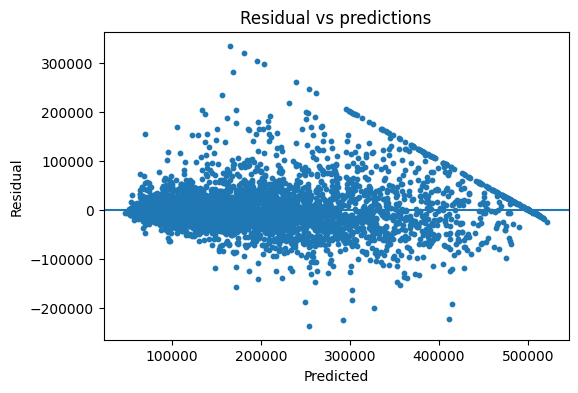

In [57]:
# residual plot

residual=y_test-test_final_pred

plt.figure(figsize=(6,4))
plt.scatter(test_final_pred,residual,s=10)
plt.axhline(0)
plt.title("Residual vs predictions")
plt.xlabel("Predicted")
plt.ylabel('Residual')
plt.show()